In the computer vision of deep learning , we give the computer capacity to see  and observe the things like deciding between cat, dog and chicjer , drawing box around cat and splitting image into road ,cat , person and sky.


In this notebook , we will learn about the diffrent pytorch vision libaries from torchvison , dataloader , etc . loading the simple dataset , use dataloader to serves dataset into batches in order to train model efffectivelu

Similalry , we will first build and train simple baseline layers , with whom other model accuracy can be contrasted .   
We will build better models with non-linearilty and cnn , compare them with the baseline model and save the best one .

Pytorch has got bundle of tools and libaries to achie this :
*   torchvision : bundle of image datasets , reayd made architecture , and common image transforms
*   torchvision.datasets : ready made dataset like fashionminst, cifrar etc along with the class to build our own datasets .
* torchvision.models: predefined architecture which we can reuse and fine tune
* torvhvision.transforms : function to convert images to tensors, resize , normalize or agument them
* torch.utils.data.Dataset : base class saying this is the dataset
* torch.utils.data.DataLoader : used to provide dataset on minibatch for the effective training of the model




lets import all of these things

In [29]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
# Note: your PyTorch version shouldn't be lower than 1.10.0 and torchvision version shouldn't be lower than 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.9.0+cu126
torchvision version: 0.24.0+cu126


Here , we will use the already inbuilt dataset  called FashionMnist . This dataset contain the 10 possible classes of clothing item ranging from tshirt, trouser, pullover , dresscoat, sandal , etc .

Since , this is already inbuilt and avaible with the pytorch , we dont need to do anything extra , we will directly setup training and test data for this

In [30]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # get test data
    download=True,
    transform=ToTensor()
)

since this are transfprmed to transer let get image and label of first dtaa of train_data

In [31]:
# See first training sample
image, label = train_data[0]
image, label


(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

let see the shape of image to get deep die into the content


In [32]:
# See first training sample shape
image.shape


torch.Size([1, 28, 28])

this torch.Size([1, 28, 28]) tells something in the pattern  that every photo in pur dataset is 1 layer of gray pixels, 28 dots tall, 28 dots wide.”​

Understanding the 3 numbers is in the form of CHW
* The first number (C) is how many “color layers” the picture has. Since it’s black‑and‑white, there’s only one layer: brightness.​

* The second number (H) is how tall the picture is, measured in pixels from top to bottom.

* The third number (W) is how wide the picture is, measured from left to right.

Extending the above point , If value of C ois 3 then it is olored photo of RGB .

SImilrly adding N = 32 in front of CHW becomes NCHW which means N ( 32 Here ) is stacked tpgether here .

since we are directly importing the training and testing data from inbuilt one , we dont know how many sample are there in the testing and trainign dataset. Lets check of that too :

In [33]:
# How many samples are there?
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

It means 60K in the traing dataset and 10K in the testing dataset .
Laos , lets observe  what what clohing items our datset contain .

In [34]:
# See classes
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

hmm, thet are tshirt , trouser, pullover, dress ,coat, sandal ,shirt, sneaker, bag and ankle boat .

more sort of alidation , lets se the first images

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

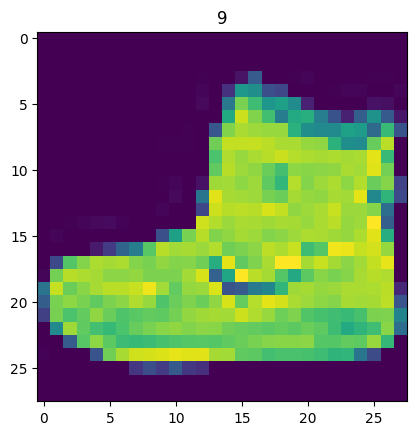

In [35]:
image, label = train_data[0]
print("Image shape:", image.shape)
plt.imshow(image.squeeze())
plt.title(label)


the image is little blur , lets make it human readable

Text(0.5, 1.0, 'Ankle boot')

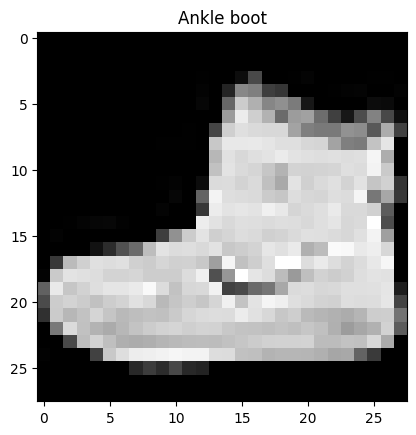

In [36]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])


still not satisfactory , but can determine we are in the right track . Lets seemore

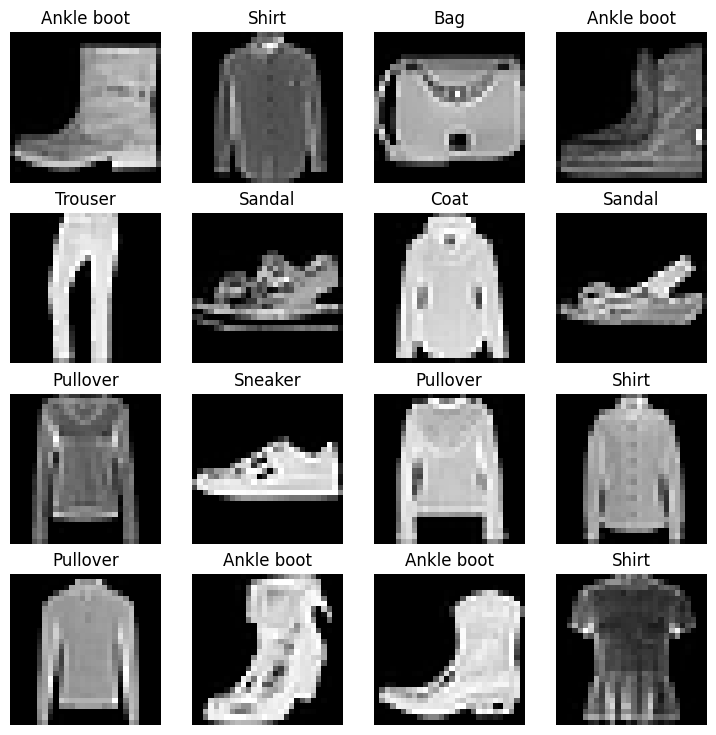

In [37]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4

for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)


Since , we cannot load all the 70k images once in the modle there is where the concept of dataloader cames and play inn

In [38]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)


With the help of this datloder we are going to build up our baseline model with the two linearty. Later its accuracy will be capared with others .

In [39]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

# 1. Load FashionMNIST (same as earlier steps)
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# 2. Create DataLoaders
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

# 3. Define baseline model (Model 0)
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.flatten = nn.Flatten()  # [1, 28, 28] -> [784]
        self.layers = nn.Sequential(
            nn.Linear(input_shape, hidden_units),  # [784] -> [hidden_units]
            nn.ReLU(),                             # non-linearity
            nn.Linear(hidden_units, output_shape)  # [hidden_units] -> [10]
        )

    def forward(self, x):
        x = self.flatten(x)      # make image 1D
        logits = self.layers(x)  # pass through linear layers
        return logits

# 4. Instantiate model, loss, optimizer
input_shape = 28 * 28
hidden_units = 10
output_shape = len(train_data.classes)  # 10

model_0 = FashionMNISTModelV0(
    input_shape=input_shape,
    hidden_units=hidden_units,
    output_shape=output_shape
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)

# 5. One simple training + testing pass (1 epoch, minimal)
EPOCHS = 1

for epoch in range(EPOCHS):
    # ----- Train -----
    model_0.train()
    train_loss = 0
    for X, y in train_dataloader:
        # forward pass
        y_pred = model_0(X)

        # loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # backward + update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # ----- Test -----
    model_0.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            test_pred = model_0(X_test)
            loss = loss_fn(test_pred, y_test)
            test_loss += loss.item()

            # predictions
            preds = test_pred.argmax(dim=1)
            correct += (preds == y_test).sum().item()
            total += y_test.size(0)

    print(f"Epoch: {epoch+1}")
    print(f"Train loss: {train_loss/len(train_dataloader):.4f}")
    print(f"Test loss: {test_loss/len(test_dataloader):.4f}")
    print(f"Test accuracy: {correct/total:.4f}")


Epoch: 1
Train loss: 0.6376
Test loss: 0.5000
Test accuracy: 0.8226


test loss of 0.5 and test acuracy . Lets visualize the prediction of some five images using it

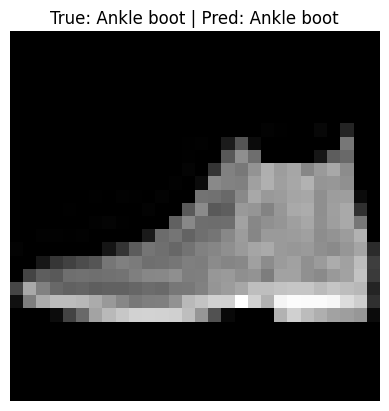

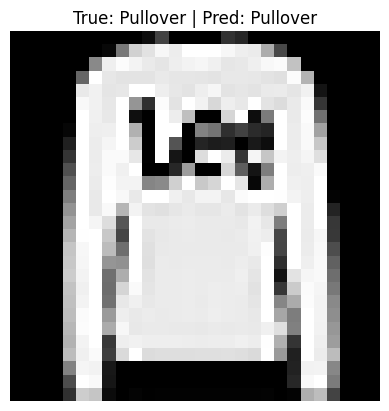

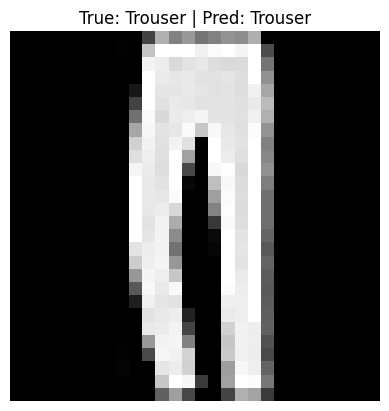

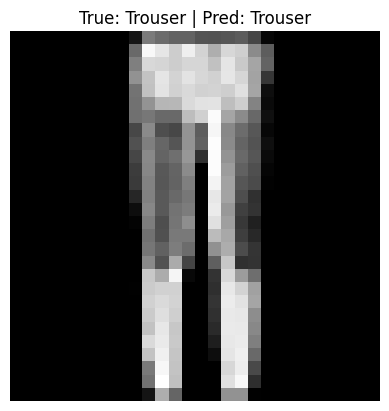

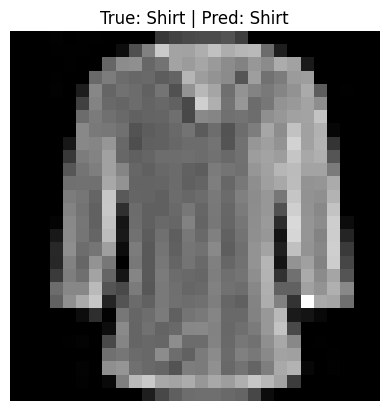

In [40]:
import matplotlib.pyplot as plt

model_0.eval()
with torch.inference_mode():
    X_sample, y_sample = next(iter(test_dataloader))   # one batch from test set
    logits  = model_0(X_sample)                        # [32, 10]
    preds   = logits.argmax(dim=1)                     # [32]

# Show first 5 images, true vs predicted labels
for i in range(5):
    img = X_sample[i].squeeze()
    true_label = class_names[y_sample[i]]
    pred_label = class_names[preds[i]]

    plt.figure()
    plt.imshow(img, cmap="gray")
    plt.axis(False)
    plt.title(f"True: {true_label} | Pred: {pred_label}")

In [41]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)
# Import accuracy metric
from helper_functions import accuracy_fn # Note: could also use torchmetrics.Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # this is also called "criterion"/"cost function" in some places
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

helper_functions.py already exists, skipping download


Getting the result of model 0

In [42]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Make predictions with the model
            y_pred = model(X)

            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y,
                                y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)

        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)

    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4999507963657379,
 'model_acc': 82.26837060702876}

we have this now : {'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4999507963657379,
 'model_acc': 82.26837060702876}

lets do all the tasks in a single devices :

In [43]:
# Setup device agnostic code
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Lets build better model with non-linearuty in the hope that we do better than the very simple baseline by letting the network learn curved/complex patterns instead of only straight‑line patterns.

In [44]:
class FashionMNISTModelV1(nn.Module):
    """
    A better model than baseline:
    - Flattens image [1, 28, 28] -> [784]
    - Two hidden layers with ReLU (non-linearity)
    - Output layer with 10 units (one per class)
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),                               # [N, 1, 28, 28] -> [N, 784]
            nn.Linear(input_shape, hidden_units),       # [N, 784] -> [N, hidden_units]
            nn.ReLU(),                                  # non-linear activation
            nn.Linear(hidden_units, hidden_units),      # [N, hidden_units] -> [N, hidden_units]
            nn.ReLU(),                                  # another non-linearity
            nn.Linear(hidden_units, output_shape)       # [N, hidden_units] -> [N, 10]
        )

    def forward(self, x):
        return self.layers(x)


lets move tha to the device and also device loss function and optimizer

In [45]:
input_shape  = 28 * 28          # 784 pixels per image
hidden_units = 64               # you can change this (e.g. 64, 128)
output_shape = len(class_names) # 10 classes

torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape, hidden_units, output_shape).to(device)
print(model_1)
loss_fn   = nn.CrossEntropyLoss()             # good for multi-class classification
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)


FashionMNISTModelV1(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


lets train

In [46]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )

        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


In [47]:
train_step(model=model_1, data_loader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, accuracy_fn=accuracy_fn)
test_step(data_loader=test_dataloader, model=model_1, loss_fn=loss_fn, accuracy_fn=accuracy_fn)



Train loss: 0.61462 | Train accuracy: 77.64%
Test loss: 0.44774 | Test accuracy: 83.91%



Evaluating this model

In [48]:
# Move values to device
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
    """Evaluates a given model on a given dataset.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.
        device (str, optional): Target device to compute on. Defaults to device.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to the target device
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        # Scale loss and acc
        loss /= len(data_loader)
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 1 results with device-agnostic code
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn,
    device=device
)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.44774019718170166,
 'model_acc': 83.90575079872204}

What the hell , {'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.5445905923843384,
 'model_acc': 79.49281150159744} clearluy shows that the accuracy has decreased . so , this may not be the right kind.

Can you try with the next architecture of CNN then ?? it is best for this type of ision data

In [49]:
# Create a convolutional neural network
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

Moving to devices and losss and optimixer

In [50]:
input_channels = 1               # grayscale
hidden_units   = 32              # number of filters
output_shape   = len(class_names)

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_channels, hidden_units, output_shape).to(device)
print(model_2)
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)


FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=10, bias=True)
  )
)


Lets make the training and evaluation loop

In [51]:
def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    epoch_loss = 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss   = loss_fn(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

def eval_one_epoch(model, dataloader, loss_fn, device):
    model.eval()
    epoch_loss = 0
    correct    = 0
    total      = 0

    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            logits = model(X)
            loss   = loss_fn(logits, y)
            epoch_loss += loss.item()

            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)

    accuracy = correct / total
    return epoch_loss / len(dataloader), accuracy


lets train and evaluate then

In [56]:
# create a dict to store Model 2 results
model2_results = {
    "model_name": "Model_2_CNN",
    "train_loss": [],
    "test_loss": [],
    "test_acc": []
}

EPOCHS = 1

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model_2, train_dataloader, loss_fn, optimizer, device)
    test_loss, test_acc = eval_one_epoch(model_2, test_dataloader, loss_fn, device)

    # save results for this epoch
    model2_results["train_loss"].append(train_loss)
    model2_results["test_loss"].append(test_loss)
    model2_results["test_acc"].append(test_acc)

    print(f"Epoch {epoch+1}: "
          f"Train loss = {train_loss:.4f}, "
          f"Test loss = {test_loss:.4f}, "
          f"Test acc = {test_acc:.4f}")


Epoch 1: Train loss = 0.2954, Test loss = 0.2969, Test acc = 0.8949


this seems to be best model till now . so comparing the resuls

In [60]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_1_results,model2_results])
compare_results

,model_name,model_loss,model_acc,train_loss,test_loss,test_acc
0,FashionMNISTModelV0,0.499951,82.268371,NaN,NaN,NaN
1,FashionMNISTModelV1,0.447740,83.905751,NaN,NaN,NaN
2,Model_2_CNN,NaN,NaN,[0.2954221625546614],[0.2969412701412702],[0.8949]


Visulizing the results

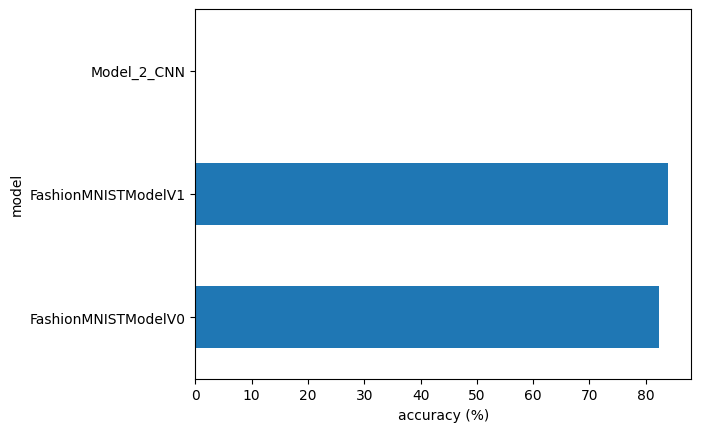

In [61]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");